# Figure 5 — the inverse problem (predicting causal drivers)

Published panels **C/D/E/F** (per-dataset inverse ROC/PR for CRISPRi & CRISPRa; mean AUC 0.953/0.913), **H/I** (composite CIPHER linear-response vs log-fold-change margin AUROC/AUPRC), and **J/K/L/M** (sci-Plex drug identification: candidate log-likelihood, top-k, ROC, PR), reproduced with the packaged CIPHER inverse. A/B/G are schematics. Engine: `notebooks/src/run_fig5.py`.

In [1]:
import os, sys
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm','tqdm.auto','tqdm.notebook','tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception: pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ("main","suppl") else os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.run_fig5 import *
from src.logutil import route_logs
DATA_DIR = os.environ["CIPHER_DATA_DIR"]
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/fig5")
os.makedirs(OUTDIR, exist_ok=True)
route_logs("fig5_inverse")
import src.run_fig5 as R
R.__dict__.update({k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR","OUTDIR")})

[logs] verbose output -> ../../resources/repro/fig5/logs/fig5_inverse.log


## Panels C / D / E / F — per-dataset inverse ROC / PR

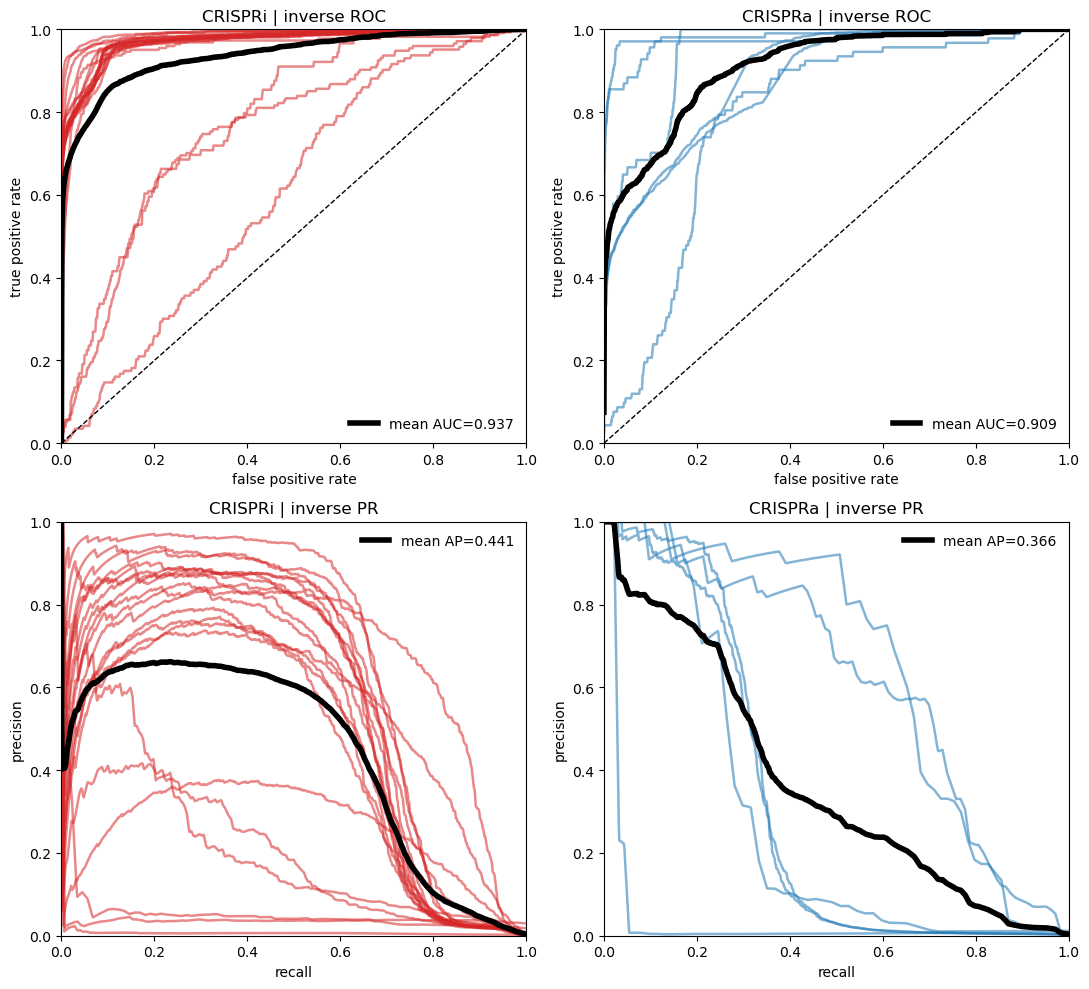

In [2]:
R.panels_cdef()

## CRISPRi identification (→ H/I composite)

In [3]:
R.run_crispri()

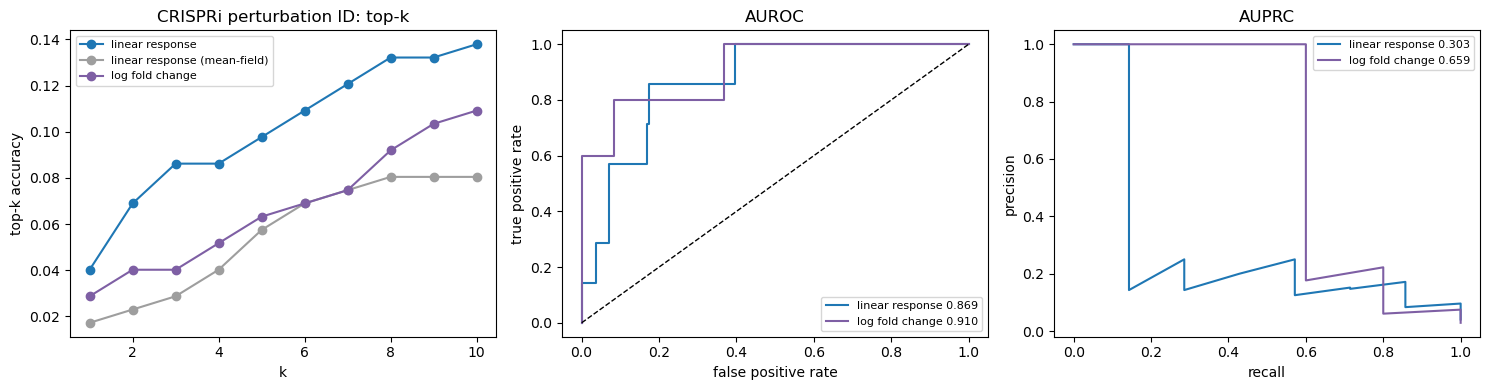

In [4]:
R.plot_crispri()

## sci-Plex drug identification — panels J / K / L / M (heavy: full-gene sci-Plex3)

In [5]:
R.run_sciplex()

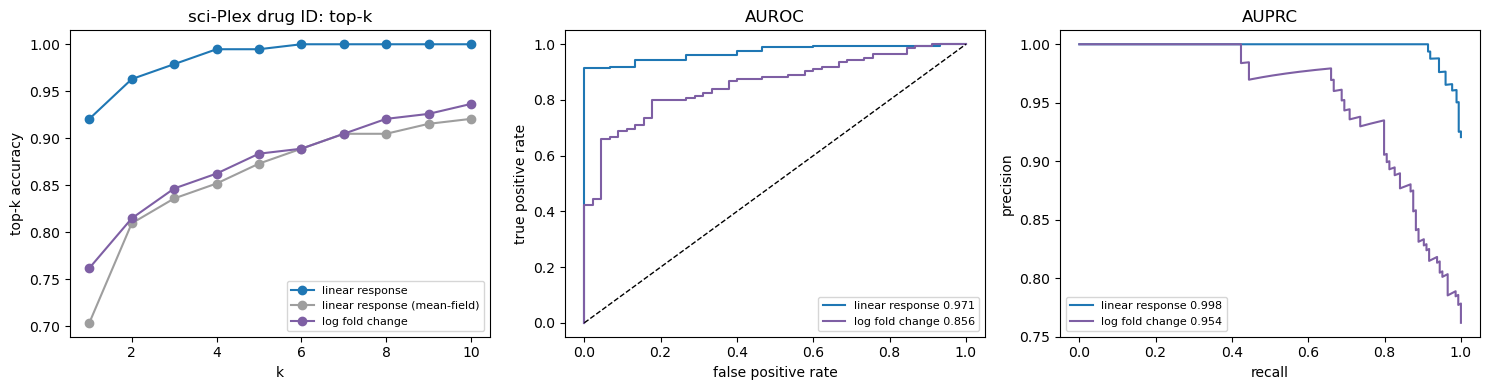

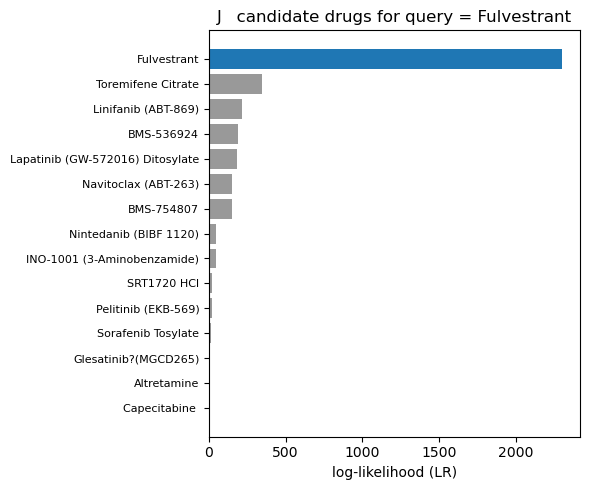

In [6]:
R.plot_sciplex()

## Panels H / I — composite margin AUROC / AUPRC (CIPHER vs LFC)

### Panels H / I — composite identification across the CRISPRi/a datasets

H and I are the **macro average over the CRISPRi/a datasets**, so every dataset is scored separately (same `mean_control_ge_1p0` / raw-count cutoffs as the rest of the paper) and the per-dataset ROC / PR curves are then averaged. Results are cached per dataset, so re-running this notebook only recomputes what changed.

In [7]:
R.run_crispri_all()

,dataset,n_cand,acc1,lr_auc,lr_ap,mf_auc,mf_ap,lfc_auc,lfc_ap
0,FrangiehIzar2021_RNA,222.0,0.108108,0.880471,0.775031,0.713580,0.458075,0.714800,0.433098
1,GSE264667_hepg2_raw_singlecell_01,230.0,0.526087,0.914323,0.943602,0.833656,0.821397,0.824762,0.844038
2,GSE264667_jurkat_raw_singlecell_01,798.0,0.172932,0.801570,0.701400,0.852813,0.733559,0.819541,0.744898
3,Marson2025_D1_Rest_filtered,967.0,0.378490,0.846326,0.865138,0.897495,0.896945,0.921158,0.940144
4,Marson2025_D1_Stim48hr_filtered,969.0,0.202270,0.864284,0.815376,0.841520,0.765376,0.905882,0.911012
5,Marson2025_D1_Stim8hr_filtered,971.0,0.192585,0.868800,0.816683,0.845815,0.818124,0.926232,0.938447
6,Marson2025_D2_Stim48hr_filtered,979.0,0.793667,0.953451,0.989060,0.952682,0.984235,0.964612,0.991533
7,Marson2025_D2_Stim8hr_filtered,979.0,0.833504,0.968070,0.994008,0.953879,0.990632,0.977644,0.997275
8,Marson2025_D3_Rest_filtered,962.0,0.663202,0.953317,0.980758,0.915350,0.947827,0.957272,0.980940
9,Marson2025_D3_Stim48hr_filtered,965.0,0.620725,0.860072,0.935528,0.925688,0.960923,0.967179,0.989784


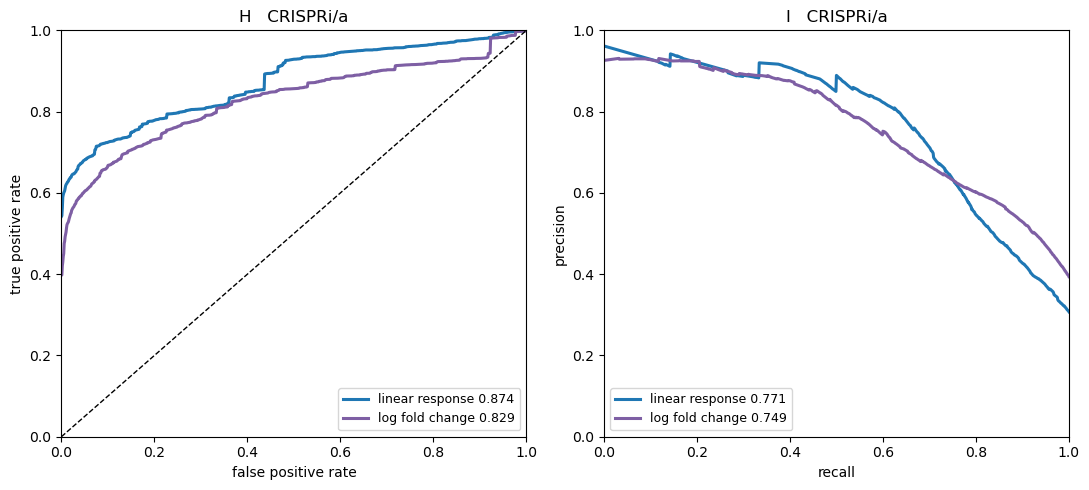

,group,method,AUROC,AUPRC
0,CRISPRi/a,linear response,0.874006,0.771067
1,CRISPRi/a,linear response (mean-field),0.842971,0.697157
2,CRISPRi/a,log fold change,0.829076,0.748524
3,sci-Plex,linear response,0.970881,0.997525
4,sci-Plex,linear response (mean-field),0.942938,0.976227
5,sci-Plex,log fold change,0.855864,0.954257


In [8]:
R.panels_hi_composite()